<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express


In [3]:
import plotly.express as px

In [4]:
#Trouver dans Google
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Mediuml'instruction permettant d'afficher toutes les colonnes d'un dataframe

In [5]:
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [6]:
#Importation du fichier web.xlsx
#Importation du fichier erp.xlsx
#importation du fichier liaison.xlsx


In [7]:
df_web = pd.read_excel('/content/web.xlsx')
df_erp = pd.read_excel('/content/erp.xlsx')
df_liaison = pd.read_excel('/content/liaison.xlsx')

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [8]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [9]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes


In [10]:
nombre_colonnes = df_erp.shape[1]
print(f"Nombre de colonnes : {nombre_colonnes}")

Nombre de colonnes : 6


In [11]:
df_erp.dtypes

,0
product_id,int64
onsale_web,int64
price,float64
stock_quantity,int64
stock_status,object
purchase_price,float64


In [12]:
valeurs_par_colonne = df_erp.count()
valeurs_par_colonne

,0
product_id,825
onsale_web,825
price,825
stock_quantity,825
stock_status,825
purchase_price,825


In [13]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [14]:


#Vérifier si il y a les lignes en doublons dans la colonne product_id


In [15]:
doublons_existent = df_erp['product_id'].duplicated().any()
print(f"Doublons dans product_id : {doublons_existent}")

Doublons dans product_id : False


In [16]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?


In [17]:
valeurs_uniques = df_erp['stock_status'].unique()
print(valeurs_uniques)

['instock' 'outofstock']


In [18]:
##elles sont liees a la colonne stock_status

In [19]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"


In [20]:
import numpy as np

df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] == 0, 'outofstock', 'instock')



In [21]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [22]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset

In [23]:
comparaison = df_erp["stock_status"] == df_erp["stock_status_2"]
somme_true = comparaison.sum()
total_lignes = len(df_erp)
print(f"Nombre de correspondances (True) : {somme_true}")
print(f"Nombre total de lignes : {total_lignes}")

if somme_true == total_lignes:
    print("Les colonnes 'stock_status' et 'stock_status_2' sont identiques.")
else:
    print(f"Les colonnes diffèrent sur {total_lignes - somme_true} ligne(s).")

Nombre de correspondances (True) : 821
Nombre total de lignes : 825
Les colonnes diffèrent sur 4 ligne(s).


In [24]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [25]:
comparaison = df_erp["stock_status"] == df_erp["stock_status_2"]

lignes_differentes = df_erp[~comparaison]

lignes_differentes

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [26]:
#Corriger la ou les données incohérentes

#Verification en utilisant le même code que plus haut pour afficher les problemes


In [27]:
df_erp['stock_quantity'] = df_erp['stock_quantity'].apply(lambda x: 0 if x < 0 else x)

In [28]:
df_erp['stock_status'] = np.where(df_erp['stock_quantity'] == 0, 'outofstock', 'instock')

In [29]:

df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] == 0, 'outofstock', 'instock')


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [30]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
#print("Nombres d'article avec un prix non renseignés: {}".format()) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"

#Afficher le prix maximum de la colonne "price"

#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)


In [31]:
prix_non_renseignes = df_erp['price'].isna().sum()
prix_negatifs_ou_nuls = (df_erp['price'] <= 0).sum()

print("Nombre d'articles avec un prix non renseigné: {}".format(prix_non_renseignes))
print("Nombre d'articles avec un prix négatif ou nul: {}".format(prix_negatifs_ou_nuls))

Nombre d'articles avec un prix non renseigné: 0
Nombre d'articles avec un prix négatif ou nul: 3


In [32]:
print("Prix minimum: {}".format(df_erp['price'].min()))
print("Prix maximum: {}".format(df_erp['price'].max()))

Prix minimum: -20.0
Prix maximum: 225.0


In [33]:
prix_negatifs = df_erp[df_erp['price'] < 0]
print("Articles avec un prix inférieur à 0:")
(prix_negatifs)

Articles avec un prix inférieur à 0:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [34]:
## on les multiplie par -1 pour avoir des valeur positives, considérant que c'est une erreur de saisie

df_erp['price'] = df_erp['price'].apply(lambda x: x*-1 if x < 0 else x)

# Vérifier si tous les prix sont maintenant positifs
print("Articles avec des prix négatifs après correction:")
(df_erp[df_erp['price'] < 0])

Articles avec des prix négatifs après correction:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


In [35]:
df_erp[df_erp["product_id"].isin([4233, 5017, 6594])]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,20.0,0,outofstock,10.33,outofstock
469,5017,0,8.0,0,outofstock,4.34,outofstock
739,6594,0,9.1,19,instock,4.61,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [36]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"

#Afficher la quantité maximum de la colonne "stock_quantity"

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)


In [37]:
print("Quantité minimum en stock: {}".format(df_erp['stock_quantity'].min()))

Quantité minimum en stock: 0


In [38]:
print("Quantité maximum en stock: {}".format(df_erp['stock_quantity'].max()))

Quantité maximum en stock: 145


In [39]:
stocks_negatifs = df_erp[df_erp['stock_quantity'] < 0]
print("Articles avec un stock inférieur à 0:")

(stocks_negatifs)

Articles avec un stock inférieur à 0:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [40]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?


In [41]:
# Afficher les valeurs distinctes dans la colonne `onsale_web`
print("Valeurs distinctes de 'onsale_web':")
(df_erp['onsale_web'].value_counts())

Valeurs distinctes de 'onsale_web':


,count
onsale_web,
1,716
0,109


In [42]:
#Supprimer la colonnecomportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".


In [43]:
df_erp = df_erp.drop(columns=['stock_status_2'])

# Vérifier que la colonne a bien été supprimée
(df_erp.head())

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [44]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"

#Afficher le prix minimum de la colonne "purchase_price"

#Afficher le prix maximum de la colonne "purchase_price"


In [45]:
# Nombre de prix non renseignés dans 'purchase_price'
print("Nombre d'articles avec un prix d'achat non renseigné: {}".format(df_erp['purchase_price'].isna().sum()))
# Prix minimum dans 'purchase_price'
print("Prix d'achat minimum: {}".format(df_erp['purchase_price'].min()))
# Prix maximum dans 'purchase_price'
print("Prix d'achat maximum: {}".format(df_erp['purchase_price'].max()))

Nombre d'articles avec un prix d'achat non renseigné: 0
Prix d'achat minimum: 2.74
Prix d'achat maximum: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [46]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques


In [47]:
print("Dimensions du dataset:", df_web.shape)
print("Nombre d'observations:", df_web.shape[0])
print("Nombre de caractéristiques:", df_web.shape[1])

Dimensions du dataset: (1513, 29)
Nombre d'observations: 1513
Nombre de caractéristiques: 29


In [48]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes


In [49]:
# Nombre de colonnes dans le dataset
("Nombre de colonnes:", df_web.shape[1])




('Nombre de colonnes:', 29)

In [50]:
# Nature des données dans chaque colonne
print("\nNature des données dans chaque colonne:")
(df_web.dtypes)




Nature des données dans chaque colonne:


,0
sku,object
virtual,int64
downloadable,int64
rating_count,int64
average_rating,float64
total_sales,float64
tax_status,object
tax_class,float64
post_author,float64
post_date,datetime64[ns]


In [51]:
# Nombre de valeurs présentes dans chaque colonne
print("\nNombre de valeurs présentes dans chaque colonne:")
(df_web.count())


Nombre de valeurs présentes dans chaque colonne:


,0
sku,1428
virtual,1513
downloadable,1513
rating_count,1513
average_rating,1430
total_sales,1430
tax_status,716
tax_class,0
post_author,1430
post_date,1430


In [52]:
#Selon vous, quelles sont les colonnes à conserver ?


In [53]:
# Suppression des colonnes inutiles
colonnes_a_supprimer = ['tax_class', 'post_content', 'post_password', 'post_content_filtered']
df_web = df_web.drop(columns=colonnes_a_supprimer, errors='ignore')

# Vérification des colonnes restantes
print("Colonnes après suppression :")
print(df_web.columns)

Colonnes après suppression :
Index(['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating',
       'total_sales', 'tax_status', 'post_author', 'post_date',
       'post_date_gmt', 'product_type', 'post_title', 'post_excerpt',
       'post_status', 'comment_status', 'ping_status', 'post_name',
       'post_modified', 'post_modified_gmt', 'post_parent', 'guid',
       'menu_order', 'post_type', 'post_mime_type', 'comment_count'],
      dtype='object')


In [54]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?


In [55]:
valeurs_sku = df_web['sku'].unique()
print("Valeurs uniques dans la colonne sku :")

(valeurs_sku)

Valeurs uniques dans la colonne sku :


array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [56]:
# les valeurs qui ne semblent pas respecter la régle de codification
incoherents = df_web[~df_web['sku'].astype(str).str.isnumeric()]
print("\nValeurs incohérentes dans la colonne SKU :")
print(incoherents['sku'].unique())



Valeurs incohérentes dans la colonne SKU :
[nan '13127-1' 'bon-cadeau-25-euros']


In [57]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
incoherents

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
#Identifier les lignes sans code articles (qui ne contienne aucune valeur dans la colonne sku)
lignes_sans_code_article = df_web[df_web['sku'].isna()]
print("\nNombre de lignes sans code d'article:", lignes_sans_code_article.shape[0])
# Afficher les lignes sans code article
pd.set_option('display.max_rows', None)
print("\nLignes sans code d'article :")
(lignes_sans_code_article)


Nombre de lignes sans code d'article: 85

Lignes sans code d'article :


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
55,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
75,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
94,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
127,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
lignes_sans_code_article.info()
lignes_sans_code_article[lignes_sans_code_article['total_sales'].notnull()]

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-null      object        
 14  comment_status 

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NaN,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [60]:
##il faut voir avec le service concerné si ces lignes doivent être conservées et complétées ou non

In [61]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
df_web['sku'].duplicated().sum()

798

In [62]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
lignes_sans_code_article=df_web[df_web['sku'].isna()]
print("\nNombre de lignes sans code d'article:", lignes_sans_code_article.shape[0])
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
lignes_sans_code_article.info()
#3 - Que constatez-vous?
## Sur ces lignes, on voit qu'il y a deux lignes qui contiennent des informations, contrairement à l'hypothèse


Nombre de lignes sans code d'article: 85
<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-nul

In [63]:

## Suppression les doublons parfaits
df_web = df_web.drop_duplicates(keep = False)

In [64]:
mask = df_web['sku'].isna()
df_web_no_sku = df_web.loc[mask]
df_web_no_sku

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NaN,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [65]:
##On supprime les lignes NaN
mask = ~ df_web['sku'].isna()
df_web = df_web.loc[mask]


In [66]:
df_web.shape

(1428, 25)

In [67]:
##On vérifie la différence entre les doublons d'un meme sku
df_web[df_web['sku']==11862]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1001,11862,0,0,0,0.0,3.0,taxable,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,Une robe rubis intense avec une très belle bri...,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [68]:
# On voit que pour un sku il y a une ligne 'product' et une ligne 'attachement'
# On compte combien de lignes correspondent aux produits.
mask =  df_web['post_type'] == 'product'
df_web_product = df_web.loc[mask]
print("Il y a", df_web_product.shape[0], "lignes correspondant à des produits.")

# On compte combien de lignes correspondent à des pièces jointes.
mask =  df_web['post_type'] == 'attachment'
df_web_attachment = df_web.loc[mask]
print("Il y a", df_web_attachment.shape[0], "lignes correspondant à des pièces jointes.")

Il y a 714 lignes correspondant à des produits.
Il y a 714 lignes correspondant à des pièces jointes.


In [69]:
print("df_web_product est composé de", df_web_product.shape[0], "lignes et", df_web_product.shape[1], "colonnes.")

df_web_product est composé de 714 lignes et 25 colonnes.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [70]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques


In [71]:
print("Dimensions du dataset:", df_liaison.shape)
print("Nombre d'observations:", df_liaison.shape[0])
print("Nombre de caractéristiques:", df_liaison.shape[1])

Dimensions du dataset: (825, 2)
Nombre d'observations: 825
Nombre de caractéristiques: 2


In [72]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes


In [73]:
print("Nombre de colonnes:", df_liaison.shape[1])
# Nature des données dans chaque colonne
print("Nature des données dans chaque colonne:")
print(df_liaison.dtypes)
# Nombre de valeurs présentes dans chaque colonne
print("Nombre de valeurs présentes dans chaque colonne:")
(df_liaison.count())

Nombre de colonnes: 2
Nature des données dans chaque colonne:
id_web        object
product_id     int64
dtype: object
Nombre de valeurs présentes dans chaque colonne:


,0
id_web,734
product_id,825


In [74]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
##Oui

In [75]:

product_id_unique_count = df_liaison['product_id'].nunique()
product_id_total_count = df_liaison['product_id'].count()

# Vérification si tous les product_id sont uniques
if product_id_unique_count == product_id_total_count:
    print("Tous les product_id sont uniques.")

Tous les product_id sont uniques.


In [76]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?


In [77]:

id_web_unique_count = df_liaison['id_web'].nunique()
id_web_total_count = df_liaison['id_web'].count()

# Vérification si tous les id_web sont uniques
if id_web_unique_count == id_web_total_count:
    print("Tous les id_web sont uniques.")


Tous les id_web sont uniques.


In [78]:
#Avons-nous des articles sans correspondances?
articles_sans_correspondance = df_web[~df_web['sku'].isin(df_liaison['id_web'])]
nombre_articles_sans_correspondance = articles_sans_correspondance.shape[0]
print("Nombre d'articles sans correspondance :", nombre_articles_sans_correspondance)

Nombre d'articles sans correspondance : 0


In [79]:
articles_sans_correspondance_erp = df_erp[~df_erp['product_id'].isin(df_liaison['product_id'])]
nombre_articles_sans_correspondance_erp = articles_sans_correspondance_erp.shape[0]
print("Nombre d'articles sans correspondance dans df_erp :", nombre_articles_sans_correspondance_erp)

Nombre d'articles sans correspondance dans df_erp : 0


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [80]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, left_on='product_id', right_on='product_id', how='left', indicator=True)

## Afficher les premières lignes du DataFrame fusionné
print("\nDataFrame Fusionné:")
(df_merge.head())

## Vérifier la forme du DataFrame fusionné
print("Nombre de lignes et colonnes dans le DataFrame fusionné :", df_merge.shape)


DataFrame Fusionné:
Nombre de lignes et colonnes dans le DataFrame fusionné : (825, 8)


In [81]:
# Afficher les premières lignes du DataFrame fusionné
print("\nDataFrame Fusionné:")
(df_merge.head())



DataFrame Fusionné:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both


In [82]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?

In [83]:
articles_sans_correspondance_erp = df_merge[df_merge['_merge'] == 'left_only']
# Afficher les résultats
print("\nArticles sans correspondance dans df_erp (left) :")
print(articles_sans_correspondance_erp)

# On supprime la colonne indicateur "_merge"
df_merge = df_merge.drop(columns=['_merge'])


Articles sans correspondance dans df_erp (left) :
Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, id_web, _merge]
Index: []


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [84]:
#Fusionnez les datasets df_merge et df_web
df_fusionne_web = pd.merge(df_merge, df_web_product, left_on='id_web', right_on='sku', how='left', indicator=True)
## Afficher les premières lignes du DataFrame fusionné
print("\nDataFrame Fusionné:")
(df_fusionne_web.head(5))
## Vérifier la forme du DataFrame fusionné
print("Nombre de lignes et colonnes dans le DataFrame fusionné :", df_fusionne_web.shape)



DataFrame Fusionné:
Nombre de lignes et colonnes dans le DataFrame fusionné : (825, 33)


In [85]:
#Avons-nous des lignes sans correspondances?
articles_sans_correspondance_web = df_fusionne_web[df_fusionne_web['_merge'] == 'left_only']

# Afficher les résultats
print("\nArticles sans correspondance dans df_web (left) :")
print(articles_sans_correspondance_web.shape)


Articles sans correspondance dans df_web (left) :
(111, 33)


In [86]:
mask = (~ df_fusionne_web['id_web'].isna()) & (df_fusionne_web['onsale_web'] == 1)
df_fusionne_web.loc[mask].shape

(713, 33)

In [87]:
## On ne garde que les lignes sans valeurs manquantes dans 'id_web'

## Equivalent à garder les lignes _merge == "both"
mask = (~ df_fusionne_web['sku'].isna()) & (~ df_fusionne_web['id_web'].isna())
df_erp_web = df_fusionne_web.loc[mask]

# On affiche le nombre de lignes et de colonnes
print("df_erp_web est composé de", df_erp_web.shape[0], "lignes et", df_erp_web.shape[1], "colonnes.")

df_erp_web est composé de 714 lignes et 33 colonnes.


In [88]:
# On supprime la colonne indicateur "_merge"
df_erp_web = df_erp_web.drop(columns=['_merge'])

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

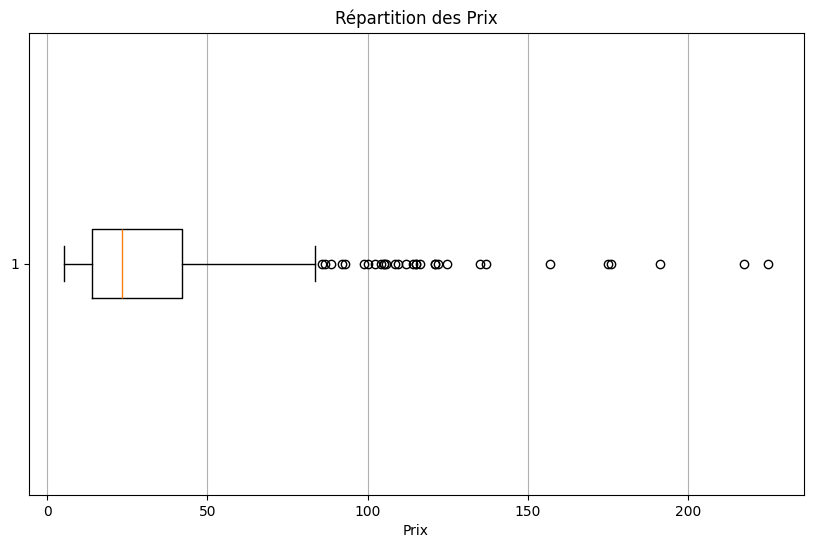

In [89]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt
if 'price' in df_erp_web.columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df_erp_web['price'], vert=False)
    plt.title('Répartition des Prix')
    plt.xlabel('Prix')
    plt.grid(axis='x')
    plt.show()
else:
    print("La colonne 'price' n'existe pas dans le DataFrame.")

In [90]:
#Autre méthode avec plotly express
!pip install plotly
import plotly.express as px


In [91]:
#Representation graphique en nuage de points:
df_prices = df_erp_web[["price"]]

# Création d'une boîte à moustaches
fig = px.box(df_prices, y='price', title="Répartition des prix", points="all")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [92]:
#Calculer la moyenne du prix

#Calculer l'écart-type du prix

#Calculer le Z-score


In [93]:
mean_price = df_prices['price'].mean()
print(f"Moyenne du prix : {mean_price}")

std_price = df_prices['price'].std()
print(f"Ecart-type du prix : {std_price}")

z_scores = (df_prices['price'] - mean_price) / std_price
print("Z-scores :")
print(z_scores)

Moyenne du prix : 32.33368347338936
Ecart-type du prix : 27.5963324191972
Z-scores :
0     -0.294738
1      0.071253
2     -0.417943
3     -0.660729
4      0.495222
5      0.071253
6      0.013274
7     -0.041081
8      1.002536
9      0.372017
10     1.727270
11    -0.508534
12    -0.345469
13    -0.472298
14    -0.381706
15    -0.892643
16     0.049511
17     0.433620
18     1.422882
20    -0.711460
21    -0.856407
22    -0.856407
23    -0.856407
24    -0.740449
25    -0.740449
26    -0.646234
27    -0.649857
28    -0.465050
29    -0.417943
30    -0.374459
31    -0.570137
32     1.002536
33    -0.323727
34     0.031392
35    -0.012092
36     1.647549
37    -0.711460
38    -0.638986
39    -0.662540
40    -0.341846
41     0.422749
42     0.169092
43     0.241565
44    -0.555642
45    -0.330975
46    -0.483169
47    -0.577384
48    -0.649857
51    -0.675223
52    -0.715084
53    -0.345469
54    -0.707836
55    -0.370835
56    -0.707836
57    -0.599126
58    -0.599126
59    -0.581008
60 

In [94]:
#Quel est le seuil prix dont z-score est supérieur à 3?
z_score_threshold = 3
price_threshold = z_score_threshold * std_price + mean_price

# Afficher le seuil de prix
print(f"Seuil de prix pour un Z-score supérieur à {z_score_threshold}: {price_threshold}")

Seuil de prix pour un Z-score supérieur à 3: 115.12268073098096


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [95]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
stats = df_prices['price'].describe()

# Afficher les résultats
print(stats)

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64


In [96]:
#Définissez un seuil pour les articles "outliers" en prix
Q1 = df_prices['price'].quantile(0.25)
Q3 = df_prices['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Seuil inférieur : {lower_bound}")
print(f"Seuil supérieur : {upper_bound}")

Seuil inférieur : -27.956250000000004
Seuil supérieur : 84.09375


In [97]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers = df_prices[(df_prices['price'] < lower_bound) | (df_prices['price'] > upper_bound)]

## Calculer le nombre d'articles et la proportion
nombre_articles_outliers = outliers.shape[0]
nombre_total_articles = df_prices.shape[0]
proportion_outliers = nombre_articles_outliers / nombre_total_articles * 100
min_outliers = outliers['price'].min()
max_outliers = outliers['price'].max()
print("Il y a", nombre_articles_outliers, "outliers dans la colonne 'price'. Les prix vont de", min_outliers, "€ à", max_outliers, "€")

Il y a 31 outliers dans la colonne 'price'. Les prix vont de 85.6 € à 225.0 €


In [98]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
###bien que ces valeurs soient considérées comme des outliers, elles ne sont pas aberrantes et ne nécessitent pas d'intervention.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [99]:
##############################
# Calculer le CA du site web #
##############################
#Créez une colonne calculant le CA par article
df_erp_web['CA'] = df_erp_web["price"]*df_erp_web["total_sales"]
print(df_erp_web[['product_id', 'total_sales', 'price', 'CA']].head(5))
#Calculez la somme de la colonne "ca_par_article"
ca_total = df_erp_web['CA'].sum()
#Ce résultat correspond au chiffre d'affaire du site web
print(f"Chiffre d'affaire total du site web : {ca_total}")

   product_id  total_sales  price     CA
0        3847          6.0   24.2  145.2
1        3849          9.0   34.3  308.7
2        3850          0.0   20.8    0.0
3        4032         12.0   14.1  169.2
4        4039          3.0   46.0  138.0
Chiffre d'affaire total du site web : 143680.09999999998


In [100]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_erp_web = df_erp_web.sort_values(by='CA', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_erp_web = df_erp_web.reset_index(drop=True)
#Afficher les 20 premier articles en CA
top_20_articles_ca = df_erp_web.head(20)
(top_20_articles_ca)
#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px
fig = px.bar(
    top_20_articles_ca,
    x='post_title',
    y='CA',
    title='Top 20 Articles en Chiffre d\'Affaires',
    labels={'post_title': 'Nom du Produit', 'CA': 'Chiffre d\'Affaires'},
    text_auto=True
)
fig.show()


In [101]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
ca_total = df_erp_web['CA'].sum()
df_erp_web['part_ca'] = df_erp_web['CA'] / ca_total * 100
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_erp_web['cumsum_part_ca'] = df_erp_web['part_ca'].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
articles_80_percent = df_erp_web[df_erp_web['cumsum_part_ca'] <= 80]
# Afficher le nombre d'articles
nombre_articles = len(articles_80_percent)
print(f"Nombre d'articles représentant 80% du CA : {nombre_articles}")
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"Proportion des articles représentant 80% du CA : {nombre_articles / len(df_erp_web) * 100:.2f}%")


Nombre d'articles représentant 80% du CA : 434
Proportion des articles représentant 80% du CA : 60.78%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [102]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_erp_web = df_erp_web.sort_values(by='total_sales', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_erp_web = df_erp_web.reset_index(drop=True)
#Afficher les 20 premier articles en quantité
top_20_articles_quantite = df_erp_web.head(20)
top_20_articles_quantite[['product_id', 'total_sales', 'CA']]

,product_id,total_sales,CA
0,4867,36.0,356.4
1,4203,27.0,267.3
2,4275,24.0,357.6
3,4726,22.0,279.4
4,4647,22.0,627.0
5,5826,20.0,824.0
6,6129,20.0,104.0
7,4220,18.0,208.8
8,5803,17.0,290.7
9,6569,17.0,493.0


In [103]:
#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px
fig = px.bar(
    top_20_articles_quantite,
    x='post_title',
    y='total_sales',
    title='Top 20 Articles en Quantité Vendue', text_auto=True
)
fig.show()

In [104]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_erp_web['part_quantite'] = df_erp_web['total_sales'] / df_erp_web['total_sales'].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_erp_web['cumsum_part_quantite'] = df_erp_web['part_quantite'].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
articles_80_percent_quantite = df_erp_web[df_erp_web['cumsum_part_quantite'] <= 0.8]
# Afficher le nombre d'articles
nombre_articles = len(articles_80_percent_quantite)
print(f"Nombre d'articles représentant 80% des ventes en quantité : {nombre_articles}")
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"Proportion des articles représentant 80% des ventes en quantité : {nombre_articles / len(df_erp_web) * 100:.2f}%")


Nombre d'articles représentant 80% des ventes en quantité : 433
Proportion des articles représentant 80% des ventes en quantité : 60.64%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [105]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np
#Création de la colonne Rotation de stock
df_erp_web['Rotation_stock'] = df_erp_web['stock_quantity'] / df_erp_web['total_sales']
#Remplacement des "inf" par 0
df_erp_web['Rotation_stock'] = df_erp_web['Rotation_stock'].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_erp_web = df_erp_web.sort_values(by='Rotation_stock', ascending=False)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(df_erp_web.head(20), x='post_name', y='Rotation_stock', title='Flop 20 des produits qui ont le plus de mois de stock')
fig.show()

In [106]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_erp_web['Valorisation_stock_euros'] = df_erp_web['stock_quantity'] * df_erp_web['price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
df_erp_web['Valorisation_stock_euros'].sum()

494637.89999999997

In [107]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
df_erp_web['stock_quantity'].sum()

16740

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [108]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
##Prix HT = Prix TTC ÷ (1 + Taux de TVA)

df_erp_web['prix_HT'] = df_erp_web['price'] /(1+0.2)
#Création de la colonne Taux de marge
df_erp_web['taux_marge'] = (df_erp_web['prix_HT'] - df_erp_web['purchase_price']) / df_erp_web['prix_HT']

#Afficher le prix minimum de la colonne "taux_marge"
print("Prix minimum de la colonne 'taux_marge' :", df_erp_web['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Prix maximum de la colonne 'taux_marge' :", df_erp_web['taux_marge'].max())


Prix minimum de la colonne 'taux_marge' : -6.3498814229249
Prix maximum de la colonne 'taux_marge' : 0.477568


In [109]:
#affichage de la ligne avec un taux de marge inférieur à 0
df_erp_web[df_erp_web['taux_marge'] < 0]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,CA,part_ca,cumsum_part_ca,part_quantite,cumsum_part_quantite,Rotation_stock,Valorisation_stock_euros,prix_HT,taux_marge
697,4355,1,12.65,97,instock,77.48,12589,12589,0.0,0.0,0.0,0.0,0.0,taxable,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,0.0,0.0,100.0,0.0,1.0,0.0,1227.05,10.541667,-6.349881


In [110]:
#création d'un dataframe avec les taux positifs
df_taux_positif = df_erp_web[df_erp_web['taux_marge'] > 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Prix minimum de la colonne 'taux_marge' :", df_taux_positif['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Prix maximum de la colonne 'taux_marge' :", df_taux_positif['taux_marge'].max())


Prix minimum de la colonne 'taux_marge' : 0.22778625954198473
Prix maximum de la colonne 'taux_marge' : 0.477568


In [111]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge_moyen = df_taux_positif.groupby('product_type')['taux_marge'].mean()
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(df_taux_marge_moyen, x=df_taux_marge_moyen.index, y=df_taux_marge_moyen.values, title='Taux de Marge par Type de Produit', text_auto=True)
fig.show()



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

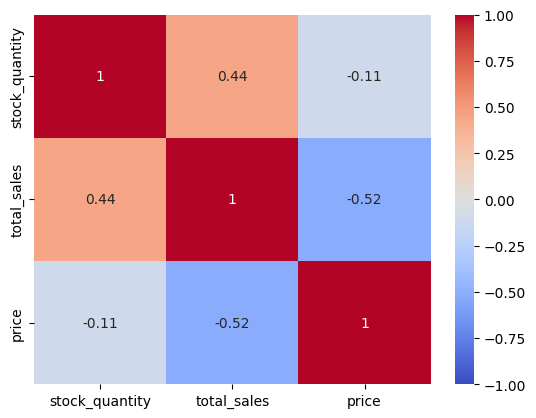

In [118]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns
#Création d'un heatmap de correlation avec les variables stock, sales et price
sns.heatmap(df_erp_web[['stock_quantity', 'total_sales', 'price']].corr(), vmin=-1, vmax=1, annot=True, cmap='coolwarm')
#on peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(df_erp_web[['stock_quantity', 'total_sales', 'price']].corr()))

In [113]:
#Que peut-on conclure des correlations ?
#Le prix influence modérément les ventes (corrélation négative), tandis que les stocks ont un impact plus limit


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [114]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.
df_erp_web.to_excel('df_erp_web.xlsx', index=False)

